# **Height Prediction using DECISION TREE**

### *Import Dataset*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### *Load Dataset from Local directory*

In [4]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (1).csv


### *Load Dataset*

In [5]:
dataset = pd.read_csv('dataset.csv')

### *Summarize Dataset*

In [6]:
print(dataset.shape)
print(dataset.head(5))

(71, 2)
   Age  Height
0   10     138
1   11     138
2   12     138
3   13     139
4   14     139


### *Segregate Dataset into Input X & Output Y*

In [8]:
X = dataset.iloc[:, :-1].values

In [9]:
Y = dataset.iloc[:, -1].values

### *Splitting Dataset for Testing our Model*

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.20,random_state=0)

### *Training Dataset using Decision Tree*

In [11]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=5,
    random_state=0
)

model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=0)

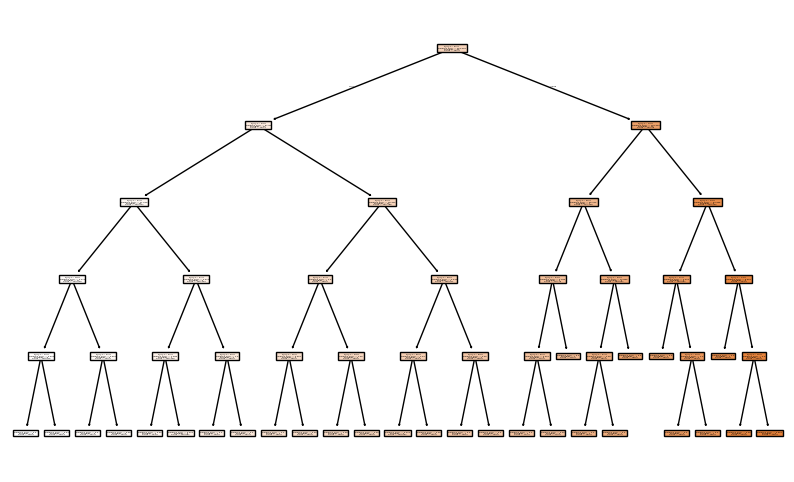

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,6))
plot_tree(model, filled=True)
plt.show()

In [13]:
age = int(input("Enter Age: "))

predicted_height = model.predict([[age]])

print("Predicted Height:", predicted_height[0])

Enter Age: 23
Predicted Height: 142.5


### *Visualizing Graph*

/tmp/ipykernel_1007/775331035.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_val = np.arange(min(x_train), max(x_train), 0.1)


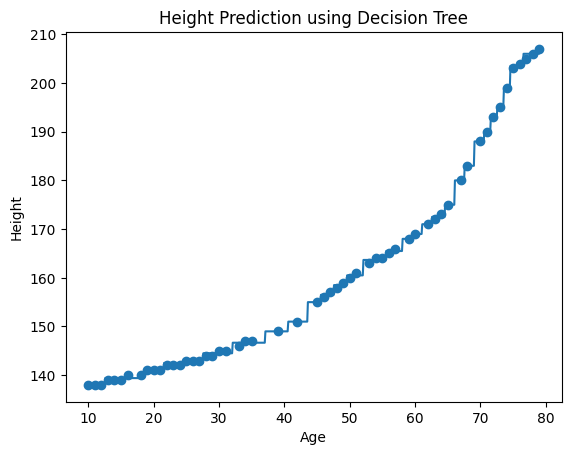

In [14]:
X_val = np.arange(min(x_train), max(x_train), 0.1)
X_val = X_val.reshape((len(X_val), 1))

plt.scatter(x_train, y_train)
plt.plot(X_val, model.predict(X_val))

plt.title('Height Prediction using Decision Tree')
plt.xlabel('Age')
plt.ylabel('Height')

plt.show()

### *Prediction for all test data for validation*

In [16]:
ypred = model.predict(x_test)

from sklearn.metrics import r2_score,mean_squared_error
mse = mean_squared_error(y_test,ypred)
r2score = r2_score(y_test, ypred)
rmse=np.sqrt(mse)
print("Root Mean Square Error:", rmse)
print("R2 Score:", r2score)
print("Model Accuracy:", r2score*100, "%")

Root Mean Square Error: 1.5419804485478104
R2 Score: 0.992446298806431
Model Accuracy: 99.2446298806431 %
